In [1]:
from typing import TypedDict
class SomeState(TypedDict):
    att1: str
    att2: str
# This is basically defining the structure of the state that will move through your LangGraph.
# You're importing TypedDict from Python's typing module. TypedDict allows you to define:
# What keys should a dictionary have, and what type of value should each key contain?
# The state carries information from one node to another.
# TypedDict doesn't create an actual dictionary by itself.It mainly tells Python/LangGraph:
# "This is the expected structure of my state."
# sp basically the code means:
# "My state is expected to be a dictionary containing att1 and att2, and both values should be strings."
# That's the main idea you need before moving to the next LangGraph code.
#SomeState is a name you choose.att1 and att2 These are dictionary key names / state field names
# you may give any meaningful names as per requirement
# class FinancingState(TypedDict):
#     customer_type: str
#     vehicle_type: str
#     monthly_income: str
#     recommendation: str
# SomeState, att1, and att2 are names chosen by the developer; TypedDict and str are Python constructs/types.

In [2]:
def some_function(state: SomeState):
    state['att1'] = "Value Changed by node some_function()"
    return state
# This function is basically a LangGraph node that receives the current state, changes one field, and sends the updated state forward.
# state: SomeState -It tells Python: "I expect state to follow the structure defined by SomeState
# next line is simply updating the att1 values from blank to "value changed by node some_function"
# return state means - The function sends the updated state back.
# This function says: "Take the current state, change the value of att1, and return the updated stat

In [3]:
# One subtle but important point: state is not a variable that you created beforehand in this code.
# LangGraph will supply it when it executes the node.
# That's why understanding the State → Node → Updated State flow is key to understanding LangGraph.

In [4]:
!pip install -U langgraph

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 250.2/250.2 kB 7.3 MB/s eta 0:00:00
  Attempting uninstall: langgraph
    Found existing installation: langgraph 1.2.11
    Uninstalling langgraph-1.2.11:
      Successfully uninstalled langgraph-1.2.11


In [5]:
# StateGraph = the overall workflow
# Node       = one step in the workflow
# State      = information being passed between steps

In [7]:
from langgraph.graph import StateGraph
#StateGraph is a LangGraph class that lets you create a graph/workflow where state moves between nodes.

In [8]:
graph = StateGraph(SomeState)
#"Create a graph whose state follows the structure defined by SomeState."

In [9]:
graph.add_node('node1', some_function)
# "Add a node called node1 to my graph, and when this node runs, execute some_function."

In [10]:
# so till this point what we did
# SomeState
#    │
#    │ defines the structure
#    ▼
# StateGraph
#    │
#    │ contains
#    ▼
#  node1
#    │
#    │ executes
#    ▼
# some_function()
#    │
#    │ changes
#    ▼
# att1

# At this point, you have created the graph and added a node,
# but you haven't told LangGraph how the graph should START and where it should GO next.

In [11]:
from langgraph.graph.state import END
# END is a special marker provided by LangGraph.

In [12]:
graph.add_edge("node1", END)
# After node1 finishes, stop the graph.

In [13]:
graph.set_entry_point('node1')
# "Start my graph from node1." Tell LangGraph where to start

In [15]:
compiled_graph = graph.compile()

# compile() basically says: # "Okay, take this graph definition and turn it into an executable LangGraph application."
# After compilation, compiled_graph is what you actually use to run the workflow.

In [17]:
from IPython.display import Image

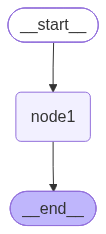

In [18]:
Image(compiled_graph.get_graph().draw_mermaid_png())

In [19]:
# the key distinction to remember:

# add_node() → What work should be done?
# add_edge() → What happens after this node?
# set_entry_point() → Where do we start?
# compile() → Make the defined graph executable
# invoke() → Actually run it

In [20]:
result = compiled_graph.invoke({
    "att1": "Original Value",
    "att2": "Hello"
})

# execute the graphs  and next line print result

In [21]:
print(result)

{'att1': 'Value Changed by node some_function()', 'att2': 'Hello'}


In [22]:
result = compiled_graph.invoke({
    "att1": "HOW ARE YOU",
    "att2": "HEY"
})

In [23]:
print(result)

{'att1': 'Value Changed by node some_function()', 'att2': 'HEY'}


# **MULTI NODE EXAMPLE**

In [24]:
# ANOTHER EXAMPLE

In [25]:
class State(TypedDict):
    graph_state: str

In [26]:
def first_node(state):
    print("This is my first node")
    return {"graph_state": state['graph_state'] + "Hi, I am traveling "}

def second_node(state):
    print("This is my second node")
    return {"graph_state": state['graph_state'] + "United Kigdom - London"}

def third_node(state):
    print("This is my third node")
    return {"graph_state": state['graph_state'] + "United State of America (USA)"}

In [27]:
# The important LangGraph concept
#              STATE
#                ↓
#          ┌────────────┐
#          │ first_node │
#          └──────┬─────┘
#                 │
#          updated STATE
#                 ↓
#         ┌─────────────┐
#         │ second_node │
#         └──────┬──────┘
#                │
#         updated STATE
#                ↓
#         ┌────────────┐
#         │ third_node │
#         └──────┬─────┘
#                │
#                ↓
#               END

# each node: receives state → does something → returns updated state

In [29]:
# in case in second node langgraph updates only 1 field  - thats how flot will be
# Initial State
# ┌─────────────────────────┐
# │ customer_name = Rahul   │
# │ vehicle_type = CNG      │
# │ income = 40,000         │
# └─────────────────────────┘
#              ↓
#         first_node
#              ↓
#      returns only:
#      vehicle_type = EV
#              ↓
# LangGraph merges update
#              ↓
# ┌─────────────────────────┐
# │ customer_name = Rahul   │ ← retained
# │ vehicle_type = EV       │ ← updated
# │ income = 40,000         │ ← retained
# └─────────────────────────┘
#              ↓
#        second_node

In [31]:
# The one mental model to keep in your head for LangGraph is:

# Initial state → Node → updated state → next node → updated state → next node → END

# And:

# invoke() → gives the initial state
# state inside a node → receives the current full state
# return {...} → tells LangGraph what to update
# LangGraph → merges the update and carries the state forward

In [32]:
# Logic
import random
from typing import Literal

def decide_location(state) -> Literal["second_node", "third_node"]:
    graph_state = state['graph_state']
    if random.random() < 0.5:
        return "second_node"
    else:
        return "third_node"

In [34]:
# explanation for above code
# Python's random module lets us generate random numbers. Here we're going to randomly decide which node should run next.
# Literal is used to say: "This function is allowed to return only these specific values."
# Here: Literal["second_node", "third_node"] means:
# The function should return either "second_node" or "third_node". It is basically telling us what the possible routes are.

# function is a routing/decision function. It receives the current state:
#  It receives the current state:  state  and decides:
# Should I go to second_node?
#              OR
# Should I go to third_node?
# Notice this function is not changing the state.  It is deciding where the graph should go next.

# random.random() This generates a random number between 0 and 1. and based on value decide which node to go
#              decide_location
#                     │
#              random number
#                     │
#           ┌─────────┴─────────┐
#           │                   │
#        < 0.5               >= 0.5
#           │                   │
#           ▼                   ▼
#     second_node          third_node

In [35]:
# so the two functions that we wrote here
# Normal node
# def first_node(state):
#     return {
#         "graph_state": state["graph_state"] + "Hello"
#     }

# Its job: Process/update state.

# Routing function
# def decide_location(state):
#     return "second_node"

# Its job: Decide which node executes next.
#                  START
#                    │
#                    ▼
#               first_node
#                    │
#                    ▼
#           decide_location
#              /          \
#             /            \
#            ▼              ▼
#     second_node       third_node
#            \              /
#             \            /
#              ▼          ▼
#                   END
# This is called conditional routing.

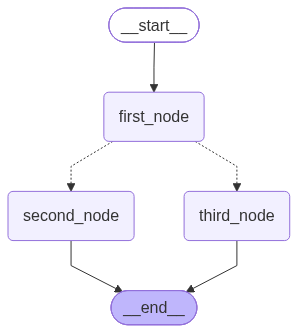

In [36]:
# Building LangGraph Model (connect with node, edge and end)

from langgraph.graph import StateGraph, START, END
from IPython.display import Image, display

builder = StateGraph(State)
builder.add_node("first_node", first_node)
builder.add_node("second_node", second_node)
builder.add_node("third_node", third_node)

builder.add_edge(START, 'first_node')
builder.add_conditional_edges("first_node", decide_location)
builder.add_edge("second_node", END)
builder.add_edge("third_node", END)

graph = builder.compile()
display(Image(graph.get_graph().draw_mermaid_png()))

In [38]:
# StateGraph → to create the graph
# START → special starting point
# END → special ending point
# Image, display → to display the graph visually in Jupyter/Colab
# builder = StateGraph(State) Create a LangGraph whose state follows the structure of State.

# start from first node and then
# builder.add_conditional_edges("first_node", decide_location) This means:
# After first_node finishes, don't automatically go to one fixed node. Instead, call decide_location() to decide where to go.
# after this assign END and draw the map

In [37]:
graph.invoke({"graph_state": "Hi, Iam Batman, "})

This is my first node
This is my third node


{'graph_state': 'Hi, Iam Batman, Hi, I am traveling United State of America (USA)'}

In [39]:
graph.invoke({"graph_state": "Hi, my name is Andrew Ng, "})

This is my first node
This is my second node


{'graph_state': 'Hi, my name is Andrew Ng, Hi, I am traveling United Kigdom - London'}

In [40]:
graph.invoke({"graph_state": "Hi, my name is priyanka chopra, "})

This is my first node
This is my second node


{'graph_state': 'Hi, my name is priyanka chopra, Hi, I am traveling United Kigdom - London'}

In [42]:
graph.invoke({"graph_state": "Hi, Iam superman, "})

This is my first node
This is my third node


{'graph_state': 'Hi, Iam superman, Hi, I am traveling United State of America (USA)'}

# **LANGGRAPHS USING TOOLS**

In [43]:
!pip install --upgrade langchain langchain-community langgraph openai langchain-openai

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.3/44.3 kB 3.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 164.7/164.7 kB 12.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.4/2.4 MB 65.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.1/2.1 MB 101.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 127.4/127.4 kB 16.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.0/1.0 MB 76.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 572.1/572.1 kB 42.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 69.4/69.4 kB 8.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 73.1/73.1 kB 9.4 MB/s eta 0:00:00
  Attempting uninstall: requests
    Found existing installation: requests 2.32.4
    Uninstalling requests-2.32.4:
      Successfully uninstalled requests-2.32.4
  Attempting uninstall: openai
    Found existing installation: openai 2.54.0
    Uninstalling openai-2.54.0:
      Successful

In [1]:
from langgraph.graph import StateGraph, START
from langchain_openai import ChatOpenAI
from langchain_core.messages import SystemMessage, HumanMessage
from langgraph.graph import MessagesState
from IPython.display import Image, display
from langgraph.graph.message import add_messages
from langgraph.prebuilt import ToolNode, tools_condition

from typing import Annotated
from typing_extensions import TypedDict


In [2]:
# from langgraph.graph import MessagesState  Earlier, you created your own state:
# class State(TypedDict):
#     graph_state: str

# But LangGraph provides a pre-built state specifically for handling messages: It is designed for conversations such as:
# User → AI → User → AI → User → AI  MessagesState = a ready-made state structure for storing chat messages.

# add_messages is a message state updater/reducer. Its job is essentially:

# When a new message comes back, add it to the existing list of messages rather than replacing the entire list.

# For example, imagine the state contains:

# messages = [
#     "Hello",
#     "Hi! How can I help?"
# ]

# A new message comes in:"Tell me about EV financing."

# add_messages helps maintain the conversation:

# Hello
# ↓
# Hi! How can I help?
# ↓
# Tell me about EV financing.
# ToolNode is a prebuilt LangGraph node that allows an LLM to execute tools.
# For example, imagine you give your AI these tools:

# calculator
# weather API
# database search
# web search

# The LLM might decide: "I need the calculator." The ToolNode can execute that tool.

# tools_condition This is used for conditional routing.
# tools_condition does something similar, but specifically for deciding:
# Does the LLM want to call a tool, or should we finish/continue normally?

# Annotated allows you to attach additional information/behavior to a type.

        #           LangGraph
        #              │
        #         StateGraph
        #              │
        #              ▼
        #       ┌────────────┐
        #       │    LLM     │
        #       │ ChatOpenAI │
        #       └─────┬──────┘
        #             │
        #      Does it need
        #         a tool?
        #         /      \
        #        /        \
        #      YES         NO
        #       ↓           ↓
        #  ToolNode        END
        #       │
        #       ↓
        #   Tool result
        #       │
        #       └──────→ LLM
 #  And MessagesState / add_messages help maintain the conversation history as the graph moves through these nodes.

In [6]:
class State(TypedDict):
  messages: Annotated[list, add_messages]

# "My state will contain a field called messages, which is a list of messages.
# Whenever messages are updated, use add_messages to add the new messages to the existing messages."
# Annotated is basically attaching extra information/instructions to the list type.
# "messages is a list, and use add_messages as the way to handle updates to this list."
# Annotated itself does not add messages. It just lets us attach add_messages to the field.
# add messages- "When a node gives me new messages, don't replace my existing messages; merge/add them using add_messages.

In [7]:
!pip install duckduckgo-search
# That package allows Python code to perform DuckDuckGo web searches.

In [8]:
from langchain_community.tools import DuckDuckGoSearchResults, DuckDuckGoSearchRun

/tmp/ipykernel_10249/2978026465.py:1: DeprecationWarning: `langchain-community` is being sunset and is no longer actively maintained. See https://github.com/langchain-ai/langchain-community/issues/674 for details and migration guidance toward standalone integration packages.
  from langchain_community.tools import DuckDuckGoSearchResults, DuckDuckGoSearchRun


In [9]:
!pip install -U ddgs

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 47.6/47.6 kB 3.9 MB/s eta 0:00:00


In [10]:
search = DuckDuckGoSearchResults()
search.invoke("Obama's first name?")

'snippet: List of presidents of the United States The White House \'s north and south sides, official residence of the president of the United States The president of the United States is the head of state and head of government of the United States, [1] indirectly elected to a four-year term via the Electoral College. [2] Under the U.S. Constitution, the officeholder leads the executive branch of the ..., title: List of presidents of the United States - Wikipedia, link: https://en.wikipedia.org/wiki/List_of_presidents_of_the_United_States, snippet: Barack Hussein Obama II was born on August 4, 1961 [3] in Kapiʻolani Medical Center for Women and Children (called Kapiʻolani Maternity & Gynecological Hospital in 1961) in Honolulu, Hawaii. [4][5] He is the first President to have been born in Hawaii. [6] His father was a black exchange student from Kenya named Barack Obama Sr. He died in a motorcycle accident in Kenya in 1982. His mother ..., title: Barack Obama - Simple English Wikipedia

In [11]:
search = DuckDuckGoSearchRun()
search.invoke("Obama's first name?")

'2 days ago - Obama was also a member of the ... a self-named group of friends who spent time together and smoked marijuana. After graduating from high school in 1979, Obama moved to Los Angeles to attend Occidental College on a full scholarship. In February 1981, Obama made his first public speech, ... 1 week ago - Barack Hussein Obama II was born on August 4, 1961 in Kapiʻolani Medical Center for Women and Children (called Kapiʻolani Maternity & Gynecological Hospital in 1961) in Honolulu, Hawaii. He is the first President to have been born in Hawaii. His father was a black exchange student from Kenya named ... July 9, 2026 - Obama is a surname. It most commonly refers to Barack Obama (born 1961), the 44th president of the United States. Obama is a common Fang masculine name in western Central Africa. August 8, 2026 - Baker subsequently married a Tanzanian man named Ndesandjo and took his surname, as did her sons Mark and David. Mark said in 2009 that Obama had been abusive to him, h

In [12]:
from langchain_community.tools import DuckDuckGoSearchRun

def search_duckduckgo(query: str):
  search = DuckDuckGoSearchRun()
  return search.invoke(query)

  # created a function to run the query

In [13]:
result = search_duckduckgo("What are AI agent?")
print(result)

1 day ago - Layer 6: Security and compliance – a protective framework for safe operation and compliance with regulatory boundaries. At this layer, security and compliance features embedded into all the AI agent stack layers are integrated together. 6 days ago - In artificial intelligence, a ... as agentic AI) expand this concept by proactively pursuing goals, making decisions, and taking actions over extended periods. Intelligent agents operate based on an objective function, which encapsulates their goals. They are designed to create ... 3 weeks ago - An artificial intelligence (AI) agent refers to a system or program that is capable of autonomously performing tasks on behalf of a user or another system. 4 days ago - What is AI agents how and why businesses use AI agents, and how to use AI agents with AWS. April 2, 2026 - AI agents are software systems that use AI to pursue goals and complete tasks on behalf of users. Learn more with Google Cloud.


In [14]:
result = search_duckduckgo("What is Newton's Third Law?")
print(result)

Newton's laws of motion are three physical laws that describe the relationship between the motion of an object and the forces acting on it. These laws, which provide the basis for Newtonian mechanics, can be paraphrased as follows: A body remains at rest, or in motion at a constant speed in a straight line, unless it is acted upon by a force. Newton's Third Law of Motion states that forces always occur in pairs. When one object exerts a force on another, the second object simultaneously exerts an equal force in the opposite direction on the first object. Statement:- "For every action, there is an equal and opposite reaction." Real-Life Examples of Newton's Third Law of Motion Inertia, F=ma, and action-reaction — Newton's three laws explained with real-world examples, worked problems, and the misconceptions people get wrong. Newton's Third Law of Motion A practical engineering guide to Newton's Third Law, action-reaction force pairs, free-body diagrams, contact forces, propulsion, colli

In [15]:
from langchain_openai import ChatOpenAI
from getpass import getpass
OPENAI_API_KEY = getpass("Enter your API key here :")

Enter your API key here :··········


In [16]:
import os
os.environ['OPENAI_API_KEY'] = OPENAI_API_KEY

In [17]:
llm = ChatOpenAI(model_name="gpt-4o-mini", temperature=0)

In [18]:
llm.invoke("Hello").content

'Hello! How can I assist you today?'

In [19]:
def add(a: int, b: int) -> int:
  "add a and b"
  return a + b

def multiply(a: int, b: int) -> int:
  "multiply a and b"
  return a * b

In [21]:
tools = [search_duckduckgo, add, multiply]
llm_with_tools = llm.bind_tools(tools)

# This is the point where you're telling the LLM: "Here are the tools you are allowed to use."
# This does not execute any of the tools.
# It creates a version of your LLM that knows about these tools and can request to use them.
# Original LLM
#      ↓
# bind_tools()
#      ↓
# LLM + knowledge of available tools
#      │
#      ├── search_duckduckgo
#      ├── add
#      └── multiply

In [23]:
def chatbot(state: State):
  return {"messages": [llm_with_tools.invoke(state["messages"])]}

# Take the conversation so far → send it to the LLM → get the LLM's response → add that response to the conversation.
#   State (messages)
#        ↓
#    LLM reads it
#        ↓
# LLM generates response
#        ↓
# Response added to messages
# If the LLM decides a tool is needed, the tool call is included in that response.
#  The actual tool execution happens later through ToolNode.

In [24]:
from langgraph.prebuilt import ToolNode, tools_condition

In [25]:
def search_duckduckgo(query: str):
  """Searches DuckDuckGo for the given query.""" # Added docstring here
  search = DuckDuckGoSearchRun()
  return search.invoke(query)

def add(a: int, b: int) -> int:
  """Adds a and b"""
  return a + b

def multiply(a: int, b: int) -> int:
  """Multiply a and b"""
  return a * b

tools = [search_duckduckgo, add, multiply]
llm_with_tools = llm.bind_tools(tools)


def chatbot(state: State):
  return {"messages": [llm_with_tools.invoke(state["messages"])]}

from langgraph.prebuilt import ToolNode, tools_condition

graph_builder = StateGraph(State)

graph_builder.add_node("assistant", chatbot)
graph_builder.add_node("tools", ToolNode(tools))
# Start the graph with the assistant (LLM)
graph_builder.add_edge(START, "assistant")
# Check the LLM response:
# If a tool is requested → go to "tools"
# If no tool is requested → END
graph_builder.add_conditional_edges("assistant", tools_condition)
# After the tool executes, send the result back to the assistant
# so the LLM can generate the final answer
graph_builder.add_edge("tools", "assistant")

react_graph = graph_builder.compile()

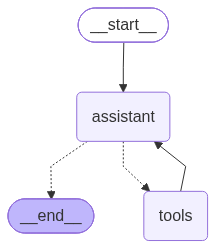

In [26]:
display(Image(react_graph.get_graph().draw_mermaid_png()))

In [27]:
response = react_graph.invoke({"messages":[HumanMessage(content="What is the weather in Hydrabad. Multiply it by 2 and add 5.")]})
# "Start my LangGraph with this user's question and run the complete workflow."
# "Run/execute the LangGraph called react_graph with this input."

In [29]:
print(response['messages'])

[HumanMessage(content='What is the weather in Bangalore. Multiply it by 2 and add 5.', additional_kwargs={}, response_metadata={}, id='8f61af5c-27cf-48ed-bda0-ec7d7ff34b53'), AIMessage(content='', additional_kwargs={'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 20, 'prompt_tokens': 110, 'total_tokens': 130, 'completion_tokens_details': {'accepted_prediction_tokens': 0, 'audio_tokens': 0, 'reasoning_tokens': 0, 'rejected_prediction_tokens': 0, 'text_tokens': None}, 'prompt_tokens_details': {'audio_tokens': 0, 'cache_write_tokens': None, 'cached_tokens': 0, 'image_tokens': None, 'text_tokens': None}}, 'model_provider': 'openai', 'model_name': 'gpt-4o-mini-2024-07-18', 'system_fingerprint': 'fp_1e58d0ce9b', 'id': 'chatcmpl-ETQXPZqDVlHoNJp95xqvHBRoQ1od3', 'service_tier': 'default', 'finish_reason': 'tool_calls', 'logprobs': None}, id='lc_run--01a0ecfa-7329-7821-8a67-36b5a01d2d15-0', tool_calls=[{'name': 'search_duckduckgo', 'args': {'query': 'current weather in 

In [30]:
response = react_graph.invoke({"messages":[HumanMessage(content="What is the weather in Bangalore. Multiply it by 2 and add 5.")]})

In [31]:
print(response['messages'])

[HumanMessage(content='What is the weather in Bangalore. Multiply it by 2 and add 5.', additional_kwargs={}, response_metadata={}, id='3c4fd31a-a5b8-4121-9971-de7cf1547784'), AIMessage(content='', additional_kwargs={'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 19, 'prompt_tokens': 110, 'total_tokens': 129, 'completion_tokens_details': {'accepted_prediction_tokens': 0, 'audio_tokens': 0, 'reasoning_tokens': 0, 'rejected_prediction_tokens': 0, 'text_tokens': None}, 'prompt_tokens_details': {'audio_tokens': 0, 'cache_write_tokens': None, 'cached_tokens': 0, 'image_tokens': None, 'text_tokens': None}}, 'model_provider': 'openai', 'model_name': 'gpt-4o-mini-2024-07-18', 'system_fingerprint': 'fp_1e58d0ce9b', 'id': 'chatcmpl-ETQXxMroWVBVWAmfuhJpcQj2eRccF', 'service_tier': 'default', 'finish_reason': 'tool_calls', 'logprobs': None}, id='lc_run--01a0ecfa-f34d-7e82-80a4-ece9f4d0ea83-0', tool_calls=[{'name': 'search_duckduckgo', 'args': {'query': 'Bangalore weather'}

In [32]:
response['messages']

[HumanMessage(content='What is the weather in Bangalore. Multiply it by 2 and add 5.', additional_kwargs={}, response_metadata={}, id='3c4fd31a-a5b8-4121-9971-de7cf1547784'),
 AIMessage(content='', additional_kwargs={'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 19, 'prompt_tokens': 110, 'total_tokens': 129, 'completion_tokens_details': {'accepted_prediction_tokens': 0, 'audio_tokens': 0, 'reasoning_tokens': 0, 'rejected_prediction_tokens': 0, 'text_tokens': None}, 'prompt_tokens_details': {'audio_tokens': 0, 'cache_write_tokens': None, 'cached_tokens': 0, 'image_tokens': None, 'text_tokens': None}}, 'model_provider': 'openai', 'model_name': 'gpt-4o-mini-2024-07-18', 'system_fingerprint': 'fp_1e58d0ce9b', 'id': 'chatcmpl-ETQXxMroWVBVWAmfuhJpcQj2eRccF', 'service_tier': 'default', 'finish_reason': 'tool_calls', 'logprobs': None}, id='lc_run--01a0ecfa-f34d-7e82-80a4-ece9f4d0ea83-0', tool_calls=[{'name': 'search_duckduckgo', 'args': {'query': 'Bangalore weather'

In [33]:
response = react_graph.invoke({"messages":[HumanMessage(content=" Multiply 8  by 2.")]})

In [34]:
print(response['messages'])

[HumanMessage(content=' Multiply 8  by 2.', additional_kwargs={}, response_metadata={}, id='7fccc41a-b3f9-445a-a011-25d6fccd7041'), AIMessage(content='', additional_kwargs={'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 17, 'prompt_tokens': 101, 'total_tokens': 118, 'completion_tokens_details': {'accepted_prediction_tokens': 0, 'audio_tokens': 0, 'reasoning_tokens': 0, 'rejected_prediction_tokens': 0, 'text_tokens': None}, 'prompt_tokens_details': {'audio_tokens': 0, 'cache_write_tokens': None, 'cached_tokens': 0, 'image_tokens': None, 'text_tokens': None}}, 'model_provider': 'openai', 'model_name': 'gpt-4o-mini-2024-07-18', 'system_fingerprint': 'fp_1e58d0ce9b', 'id': 'chatcmpl-ETQYiq6s8joYw0lSHk7G57d7I9Fl3', 'service_tier': 'default', 'finish_reason': 'tool_calls', 'logprobs': None}, id='lc_run--01a0ecfb-aefb-70f3-af5a-d0bd7bc21d67-0', tool_calls=[{'name': 'multiply', 'args': {'a': 8, 'b': 2}, 'id': 'call_bL7Nlt0aXD9QVwjbLskMy9dD', 'type': 'tool_call'}], in

In [35]:
response['messages']

[HumanMessage(content=' Multiply 8  by 2.', additional_kwargs={}, response_metadata={}, id='7fccc41a-b3f9-445a-a011-25d6fccd7041'),
 AIMessage(content='', additional_kwargs={'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 17, 'prompt_tokens': 101, 'total_tokens': 118, 'completion_tokens_details': {'accepted_prediction_tokens': 0, 'audio_tokens': 0, 'reasoning_tokens': 0, 'rejected_prediction_tokens': 0, 'text_tokens': None}, 'prompt_tokens_details': {'audio_tokens': 0, 'cache_write_tokens': None, 'cached_tokens': 0, 'image_tokens': None, 'text_tokens': None}}, 'model_provider': 'openai', 'model_name': 'gpt-4o-mini-2024-07-18', 'system_fingerprint': 'fp_1e58d0ce9b', 'id': 'chatcmpl-ETQYiq6s8joYw0lSHk7G57d7I9Fl3', 'service_tier': 'default', 'finish_reason': 'tool_calls', 'logprobs': None}, id='lc_run--01a0ecfb-aefb-70f3-af5a-d0bd7bc21d67-0', tool_calls=[{'name': 'multiply', 'args': {'a': 8, 'b': 2}, 'id': 'call_bL7Nlt0aXD9QVwjbLskMy9dD', 'type': 'tool_call'}], i